## Import libraries

In [ ]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore

2025-03-09 16:34:23.169366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741525463.193792   64557 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741525463.201055   64557 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 16:34:23.226167: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Find Path

In [2]:
def find_path(folder_name):
    f = sorted(os.listdir(f'{folder_name}'))
    name_list = []
    for i in f:
        temp_l = sorted(os.listdir(f'{folder_name}/{i}'))
        for j in temp_l:
            name_list.append(f'{folder_name}/{i}/{j}')

    grouped_files = {"adc": [], "cor": [], "hbv": [], "sag": [], "t2w": []}
    for path in name_list:
        suffix = path.split('_')[-1].split('.')[0]
        grouped_files[suffix].append(path)
    return grouped_files

In [3]:
grouped_files = find_path("picai_public_images_fold0")

## Show metadata

In [4]:
def show_metadata(g_file):
    for i in g_file:
        image = sitk.ReadImage(i)
    
        keys = image.GetMetaDataKeys()
    
        for key in keys:
            print(f"{key}: {image.GetMetaData(key)}")
        print('-' * 70)

In [5]:
show_metadata(grouped_files['cor'][:5])

0008|0020: 2019-07-02
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10000
0010|0040: M
0010|1010: 073Y
0012|0062: YES
0020|000d: 1000000
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 55
PSAD_REPORT: nan
PSA_REPORT: 7.7
----------------------------------------------------------------------
0008|0020: 2016-05-27
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10001
0010|0040: M
0010|1010: 064Y
0012|0062: YES
0020|000d: 1000001
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 102
PSAD_REPORT: 0.09
PSA_REPORT: 8.7
---------------------------------------------------

In [6]:
show_metadata(grouped_files['hbv'][:5])

0008|0020: 2019-07-02
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10000
0010|0040: M
0010|1010: 073Y
0012|0062: YES
0018|9087: 1400
0020|000d: 1000000
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 55
PSAD_REPORT: nan
PSA_REPORT: 7.7
----------------------------------------------------------------------
0008|0020: 2016-05-27
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10001
0010|0040: M
0010|1010: 064Y
0012|0062: YES
0018|9087: 1400
0020|000d: 1000001
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 102
PSAD_REPORT: 0.09
PSA_REPORT: 8.7
-------------------

In [7]:
show_metadata(grouped_files['sag'][:5])

0008|0020: 2019-07-02
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10000
0010|0040: M
0010|1010: 073Y
0012|0062: YES
0020|000d: 1000000
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 55
PSAD_REPORT: nan
PSA_REPORT: 7.7
----------------------------------------------------------------------
0008|0020: 2016-05-27
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10001
0010|0040: M
0010|1010: 064Y
0012|0062: YES
0020|000d: 1000001
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 102
PSAD_REPORT: 0.09
PSA_REPORT: 8.7
---------------------------------------------------

In [8]:
show_metadata(grouped_files['t2w'][:5])

0008|0020: 2019-07-02
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10000
0010|0040: M
0010|1010: 073Y
0012|0062: YES
0020|000d: 1000000
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 55
PSAD_REPORT: nan
PSA_REPORT: 7.7
----------------------------------------------------------------------
0008|0020: 2016-05-27
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10001
0010|0040: M
0010|1010: 064Y
0012|0062: YES
0020|000d: 1000001
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 102
PSAD_REPORT: 0.09
PSA_REPORT: 8.7
---------------------------------------------------

In [9]:
show_metadata(grouped_files['adc'][:5])

0008|0020: 2019-07-02
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10000
0010|0040: M
0010|1010: 073Y
0012|0062: YES
0020|000d: 1000000
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 55
PSAD_REPORT: nan
PSA_REPORT: 7.7
----------------------------------------------------------------------
0008|0020: 2016-05-27
0008|0060: MR
0008|0070: SIEMENS
0008|1090: Skyra
0010|0020: 10001
0010|0040: M
0010|1010: 064Y
0012|0062: YES
0020|000d: 1000001
ANONYMISATION_SCRIPT: PI-CAI anonymisation script v2.0
ITK_InputFilterName: MetaImageIO
ITK_original_direction: [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing: [UNKNOWN_PRINT_CHARACTERISTICS]

Modality: MET_MOD_UNKNOWN
PROSTATE_VOLUME_REPORT: 102
PSAD_REPORT: 0.09
PSA_REPORT: 8.7
---------------------------------------------------

## Separate DataFrame by filetype

In [10]:
def df_builder(g_file, column):
    df = pd.DataFrame(columns=column)
    
    d = dict()
    
    for i in g_file:
        image = sitk.ReadImage(i)
    
        keys = image.GetMetaDataKeys()
    
        for key, keyy in zip(keys, column):
            d[keyy] = image.GetMetaData(key)
    
        new_row = pd.DataFrame(d, index = [0])
        df = pd.concat([df, new_row], ignore_index=True)
    
    return df

In [11]:
k = ['Study Date', 'Modality', 'Manufacturer', "Manufacturer's Model Name",
     'Patient ID', "Patient's Sex", "Patient's Age", "Patient Identity Removed",
     "Study Instance UID", 'ANONYMISATION_SCRIPT', 'ITK_InputFilterName', 'ITK_original_direction',
     'ITK_original_spacing', 'Modality (Repeated)', 'PROSTATE_VOLUME_REPORT', 'PSAD_REPORT', 'PSA_REPORT']

k_hbv = ['Study_Date', 'Modality', 'Manufacturer', "Manufacturer's_Model_Name",
     'Patient_ID', "Patient's_Sex", "Patient's_Age", "Patient_Identity_Removed", "Diffusion_sensitization_factor sec/mm",
     "Study Instance_UID", 'ANONYMISATION_SCRIPT', 'ITK_InputFilterName', 'ITK_original_direction',
     'ITK_original_spacing', 'Modality_(Repeated)', 'PROSTATE_VOLUME_REPORT', 'PSAD_REPORT', 'PSA_REPORT']

df_adc = df_builder(grouped_files['adc'], column=k)
df_adc['path'] = grouped_files['adc']

df_cor = df_builder(grouped_files['cor'], column=k)
df_cor['path'] = grouped_files['cor']

df_sag = df_builder(grouped_files['sag'], column=k)
df_sag['path'] = grouped_files['sag']

df_t2w = df_builder(grouped_files['t2w'], column=k)
df_t2w['path'] = grouped_files['t2w']

df_hbv = df_builder(grouped_files['hbv'], column=k_hbv)
df_hbv['path'] = grouped_files['hbv']

df_adc

,Study Date,Modality,Manufacturer,Manufacturer's Model Name,Patient ID,Patient's Sex,Patient's Age,Patient Identity Removed,Study Instance UID,ANONYMISATION_SCRIPT,ITK_InputFilterName,ITK_original_direction,ITK_original_spacing,Modality (Repeated),PROSTATE_VOLUME_REPORT,PSAD_REPORT,PSA_REPORT,path
0,2019-07-02,MR,SIEMENS,Skyra,10000,M,073Y,YES,1000000,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,55,nan,7.7,picai_public_images_fold0/10000/10000_1000000_...
1,2016-05-27,MR,SIEMENS,Skyra,10001,M,064Y,YES,1000001,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,102,0.09,8.7,picai_public_images_fold0/10001/10001_1000001_...
2,2019-04-05,MR,SIEMENS,Skyra,10003,M,072Y,YES,1000003,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,71.5,nan,13,picai_public_images_fold0/10003/10003_1000003_...
3,2020-10-23,MR,SIEMENS,Skyra,10006,M,073Y,YES,1000006,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,27,0.23,6.2,picai_public_images_fold0/10006/10006_1000006_...
4,2012-09-21,MR,SIEMENS,Skyra,10017,M,067Y,YES,1000017,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,nan,nan,5.5,picai_public_images_fold0/10017/10017_1000017_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2020-02-21,MR,SIEMENS,Skyra,11467,M,061Y,YES,1001491,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,103,0.05,5.4,picai_public_images_fold0/11467/11467_1001491_...
296,2020-04-18,MR,SIEMENS,Skyra,11469,M,049Y,YES,1001493,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,34,0.13,4.3,picai_public_images_fold0/11469/11469_1001493_...
297,2012-08-25,MR,SIEMENS,Skyra,11471,M,071Y,YES,1001495,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,62,0.21,12.5,picai_public_images_fold0/11471/11471_1001495_...
298,2017-09-24,MR,SIEMENS,Skyra,11473,M,056Y,YES,1001497,PI-CAI anonymisation script v2.0,MetaImageIO,[UNKNOWN_PRINT_CHARACTERISTICS]\n,[UNKNOWN_PRINT_CHARACTERISTICS]\n,MET_MOD_UNKNOWN,87,0.34,29.6,picai_public_images_fold0/11473/11473_1001497_...


## EDA of Dateframes

In [12]:
print(df_adc.duplicated(k).sum())
print(df_cor.duplicated(k).sum())
print(df_hbv.duplicated(k_hbv).sum())
print(df_sag.duplicated(k).sum())
print(df_t2w.duplicated(k).sum())

0
0
0
0
0


In [13]:
df_adc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Study Date                 300 non-null    object
 1   Modality                   300 non-null    object
 2   Manufacturer               300 non-null    object
 3   Manufacturer's Model Name  300 non-null    object
 4   Patient ID                 300 non-null    object
 5   Patient's Sex              300 non-null    object
 6   Patient's Age              300 non-null    object
 7   Patient Identity Removed   300 non-null    object
 8   Study Instance UID         300 non-null    object
 9   ANONYMISATION_SCRIPT       300 non-null    object
 10  ITK_InputFilterName        300 non-null    object
 11  ITK_original_direction     300 non-null    object
 12  ITK_original_spacing       300 non-null    object
 13  Modality (Repeated)        300 non-null    object
 14  PROSTATE_V

In [14]:
df_adc['Study Date'] = pd.to_datetime(df_adc['Study Date'])
df_cor['Study Date'] = pd.to_datetime(df_cor['Study Date'])
df_sag['Study Date'] = pd.to_datetime(df_sag['Study Date'])
df_t2w['Study Date'] = pd.to_datetime(df_t2w['Study Date'])
df_hbv['Study_Date'] = pd.to_datetime(df_hbv['Study_Date'])

In [15]:
def patient_age(df, column):
    patient_age = [int(item[:-1]) for item in list(df[column])]
    df[column] = patient_age
    return df

In [16]:
patient_age(df_adc, 'Patient\'s Age')
patient_age(df_cor, 'Patient\'s Age')
patient_age(df_sag, 'Patient\'s Age')
patient_age(df_t2w, 'Patient\'s Age')
patient_age(df_hbv, "Patient's_Age" )
print('done')

done


In [17]:
def df_value_counts(df, columns):
    for column in columns:
        print(df[column].value_counts())
        print("-" * 70)

In [18]:
df_value_counts(df_adc, k)

Study Date
2019-01-16    2
2012-08-25    2
2019-02-23    2
2018-04-23    2
2012-08-23    2
             ..
2015-12-11    1
2018-11-22    1
2018-11-12    1
2015-06-13    1
2016-05-03    1
Name: count, Length: 288, dtype: int64
----------------------------------------------------------------------
Modality
MR    300
Name: count, dtype: int64
----------------------------------------------------------------------
Manufacturer
SIEMENS                    242
Philips Medical Systems     58
Name: count, dtype: int64
----------------------------------------------------------------------
Manufacturer's Model Name
Skyra         205
Ingenia        47
TrioTim        17
Prisma_fit     13
Achieva        11
Aera            4
Prisma          2
Avanto          1
Name: count, dtype: int64
----------------------------------------------------------------------
Patient ID
10129    2
10193    2
11383    2
11087    2
10540    2
        ..
10526    1
10525    1
10524    1
10522    1
11474    1
Name: count, Len

In [19]:
df_adc = df_adc.replace('nan', np.nan)
df_cor = df_cor.replace('nan', np.nan)
df_hbv = df_hbv.replace('nan', np.nan)
df_sag = df_sag.replace('nan', np.nan)
df_t2w = df_t2w.replace('nan', np.nan)

df_adc = df_adc.replace('MET_MOD_UNKNOWN', np.nan)
df_cor = df_cor.replace('MET_MOD_UNKNOWN', np.nan)
df_hbv = df_hbv.replace('MET_MOD_UNKNOWN', np.nan)
df_sag = df_sag.replace('MET_MOD_UNKNOWN', np.nan)
df_t2w = df_t2w.replace('MET_MOD_UNKNOWN', np.nan)

/tmp/ipykernel_64557/1849344122.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hbv = df_hbv.replace('MET_MOD_UNKNOWN', np.nan)


In [20]:
df_adc[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']] = df_adc[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']].astype('float64')
df_cor[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']] = df_cor[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']].astype('float64')
df_sag[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']] = df_sag[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']].astype('float64')
df_t2w[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']] = df_t2w[['PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']].astype('float64')
df_hbv[['Diffusion_sensitization_factor sec/mm', 'PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']] = df_hbv[['Diffusion_sensitization_factor sec/mm', 
                                                                                         'PSA_REPORT', 'PSAD_REPORT', 'PROSTATE_VOLUME_REPORT']].astype('float64')

In [21]:
df_adc[["Study Instance UID"]] = df_adc[["Study Instance UID"]].astype('int64')
df_cor[["Study Instance UID"]] = df_cor[["Study Instance UID"]].astype('int64')
df_sag[["Study Instance UID"]] = df_sag[["Study Instance UID"]].astype('int64')
df_t2w[["Study Instance UID"]] = df_t2w[["Study Instance UID"]].astype('int64')
df_hbv[["Study Instance_UID"]] = df_hbv[["Study Instance_UID"]].astype('int64')

In [22]:
df_adc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Study Date                 300 non-null    datetime64[ns]
 1   Modality                   300 non-null    object        
 2   Manufacturer               300 non-null    object        
 3   Manufacturer's Model Name  300 non-null    object        
 4   Patient ID                 300 non-null    object        
 5   Patient's Sex              300 non-null    object        
 6   Patient's Age              300 non-null    int64         
 7   Patient Identity Removed   300 non-null    object        
 8   Study Instance UID         300 non-null    int64         
 9   ANONYMISATION_SCRIPT       300 non-null    object        
 10  ITK_InputFilterName        300 non-null    object        
 11  ITK_original_direction     300 non-null    object        
 12  ITK_orig

## EDA of Pictures

In [23]:
for i, pic in enumerate(grouped_files['adc'][:5]):
    image = sitk.ReadImage(pic)
    print(f"picture: {i}")
    print(f"Dimention: {image.GetDimension()}")
    print(f"Spacing: {image.GetSpacing()}")
    print(f"Depth: {image.GetDepth()}")
    print(f"Direction: {image.GetDirection()}")
    print(f"Shape: {image.GetSize()}")
    print("-" * 70)

picture: 0
Dimention: 3
Spacing: (1.75438594818, 1.75438594818, 3.2999999825580133)
Depth: 31
Direction: (1.0, 0.0, 0.0, 0.0, 0.9198214958019287, 0.39233712016670375, 0.0, -0.39233712016670375, 0.9198214958019287)
Shape: (116, 114, 31)
----------------------------------------------------------------------
picture: 1
Dimention: 3
Spacing: (2.0, 2.0, 3.6000000778885344)
Depth: 21
Direction: (0.9996148108062515, -1.6670999975453016e-11, -0.02775301815627119, 0.00043710598429775216, 0.999875963366245, 0.01574378673580096, 0.027749575765060076, -0.015749853409600077, 0.9994908219500744)
Shape: (120, 128, 21)
----------------------------------------------------------------------
picture: 2
Dimention: 3
Spacing: (2.0, 2.0, 3.0000000803421303)
Depth: 23
Direction: (1.0, -4.896999999999999e-12, 5.819077202182931e-17, 4.755630674582797e-12, 0.9711342771144598, 0.23853346895849994, -1.1681549085430961e-12, -0.23853346895849994, 0.9711342771144598)
Shape: (120, 128, 23)
---------------------------

In [24]:
def show_image(path):
    image = sitk.ReadImage(path)

    image_array = sitk.GetArrayFromImage(image)
    
    plt.figure(figsize=(15, 15))
    for i in range(image.GetDepth()):
        plt.subplot(4, 8, i+1)
        plt.imshow(image_array[i], cmap='gray')
        plt.title(f"Slice {i}")
    plt.tight_layout()
    plt.show()

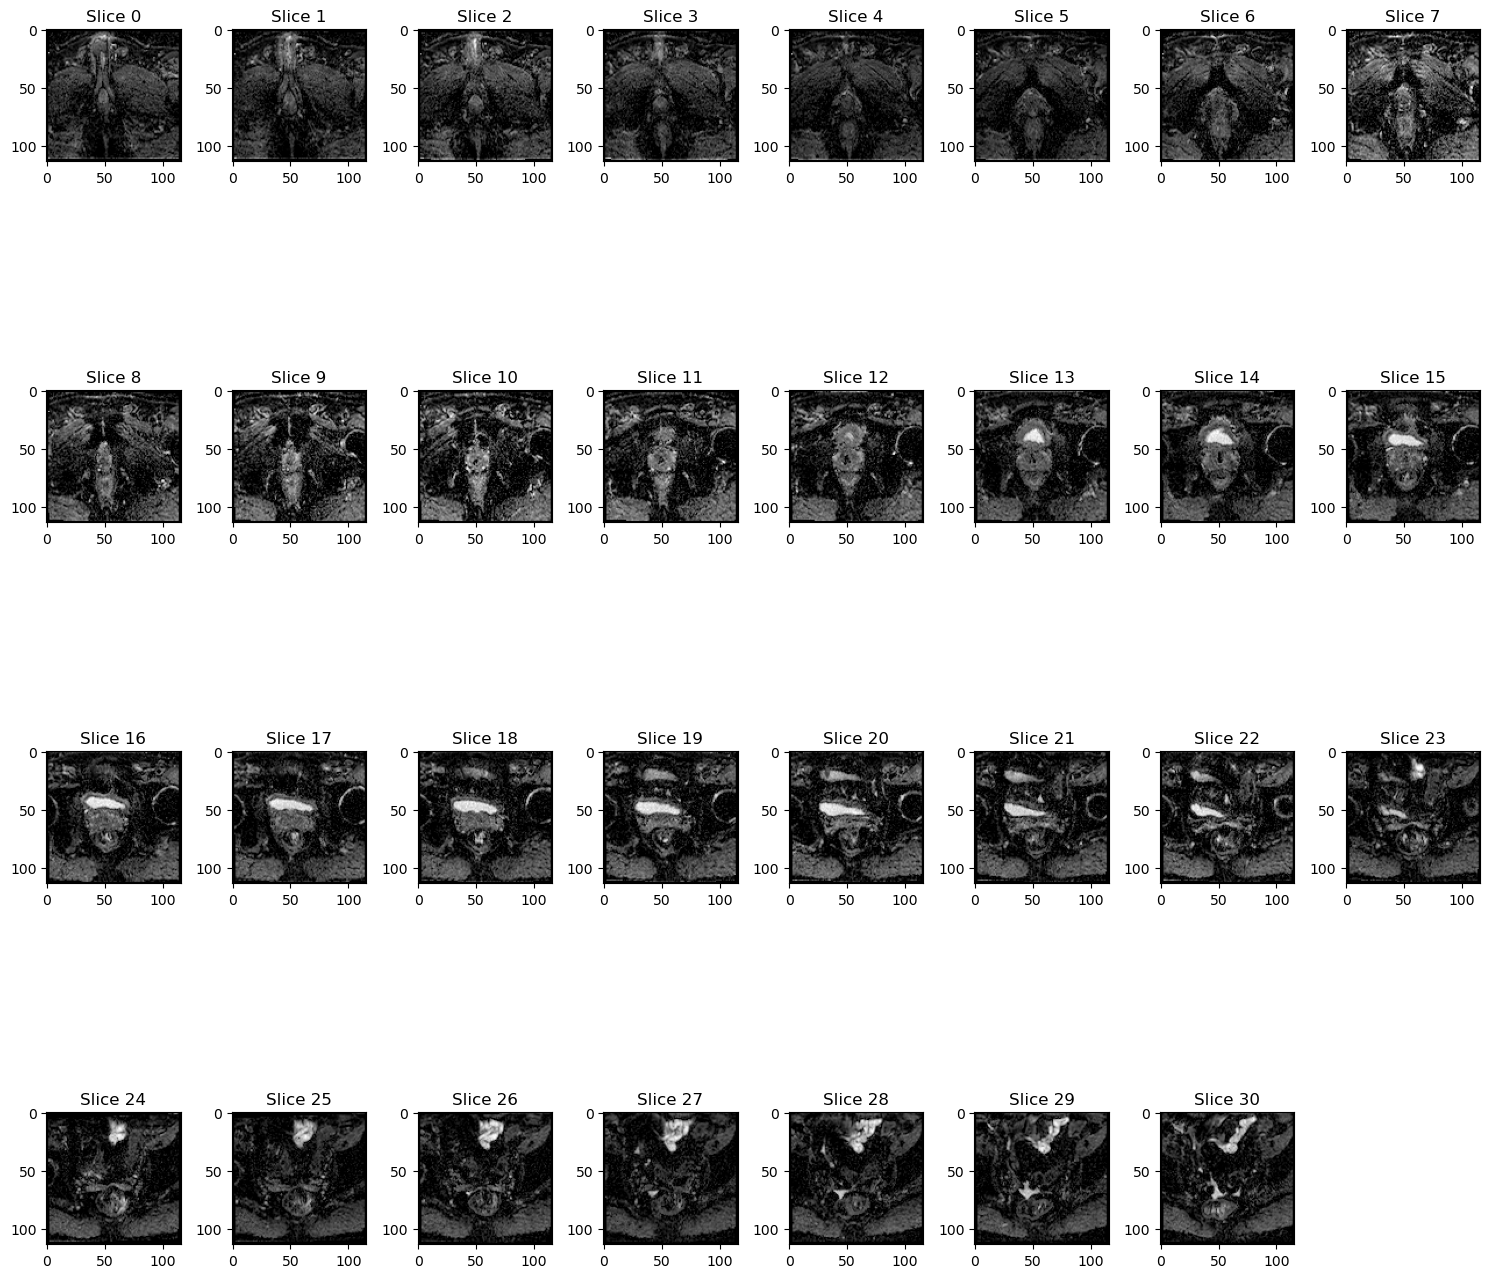

In [25]:
show_image(grouped_files['adc'][0])

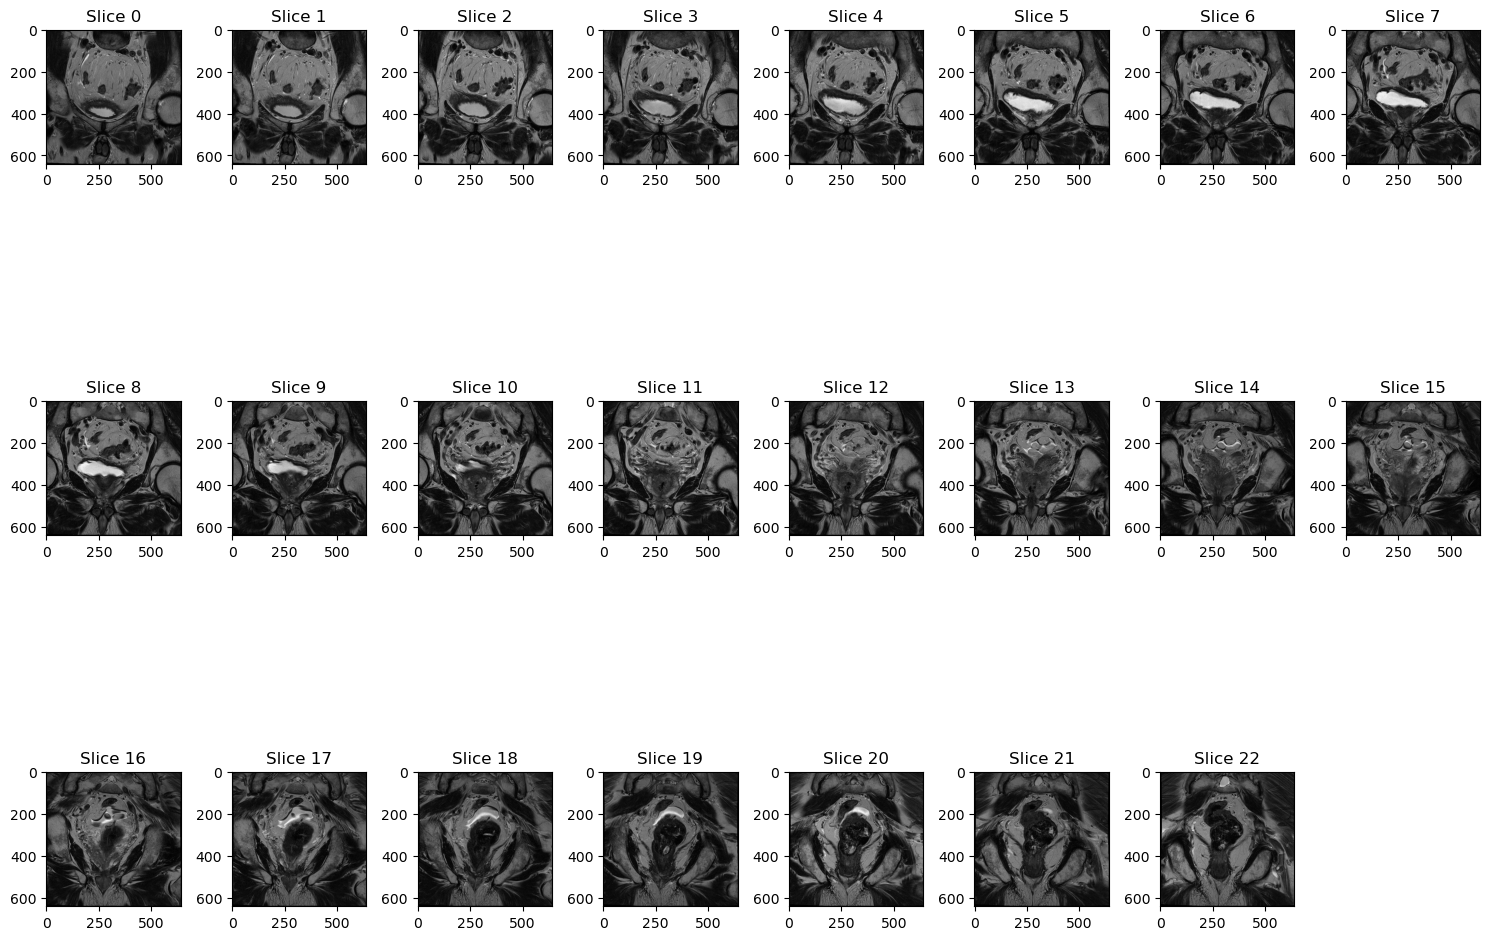

In [26]:
show_image(grouped_files['cor'][0])

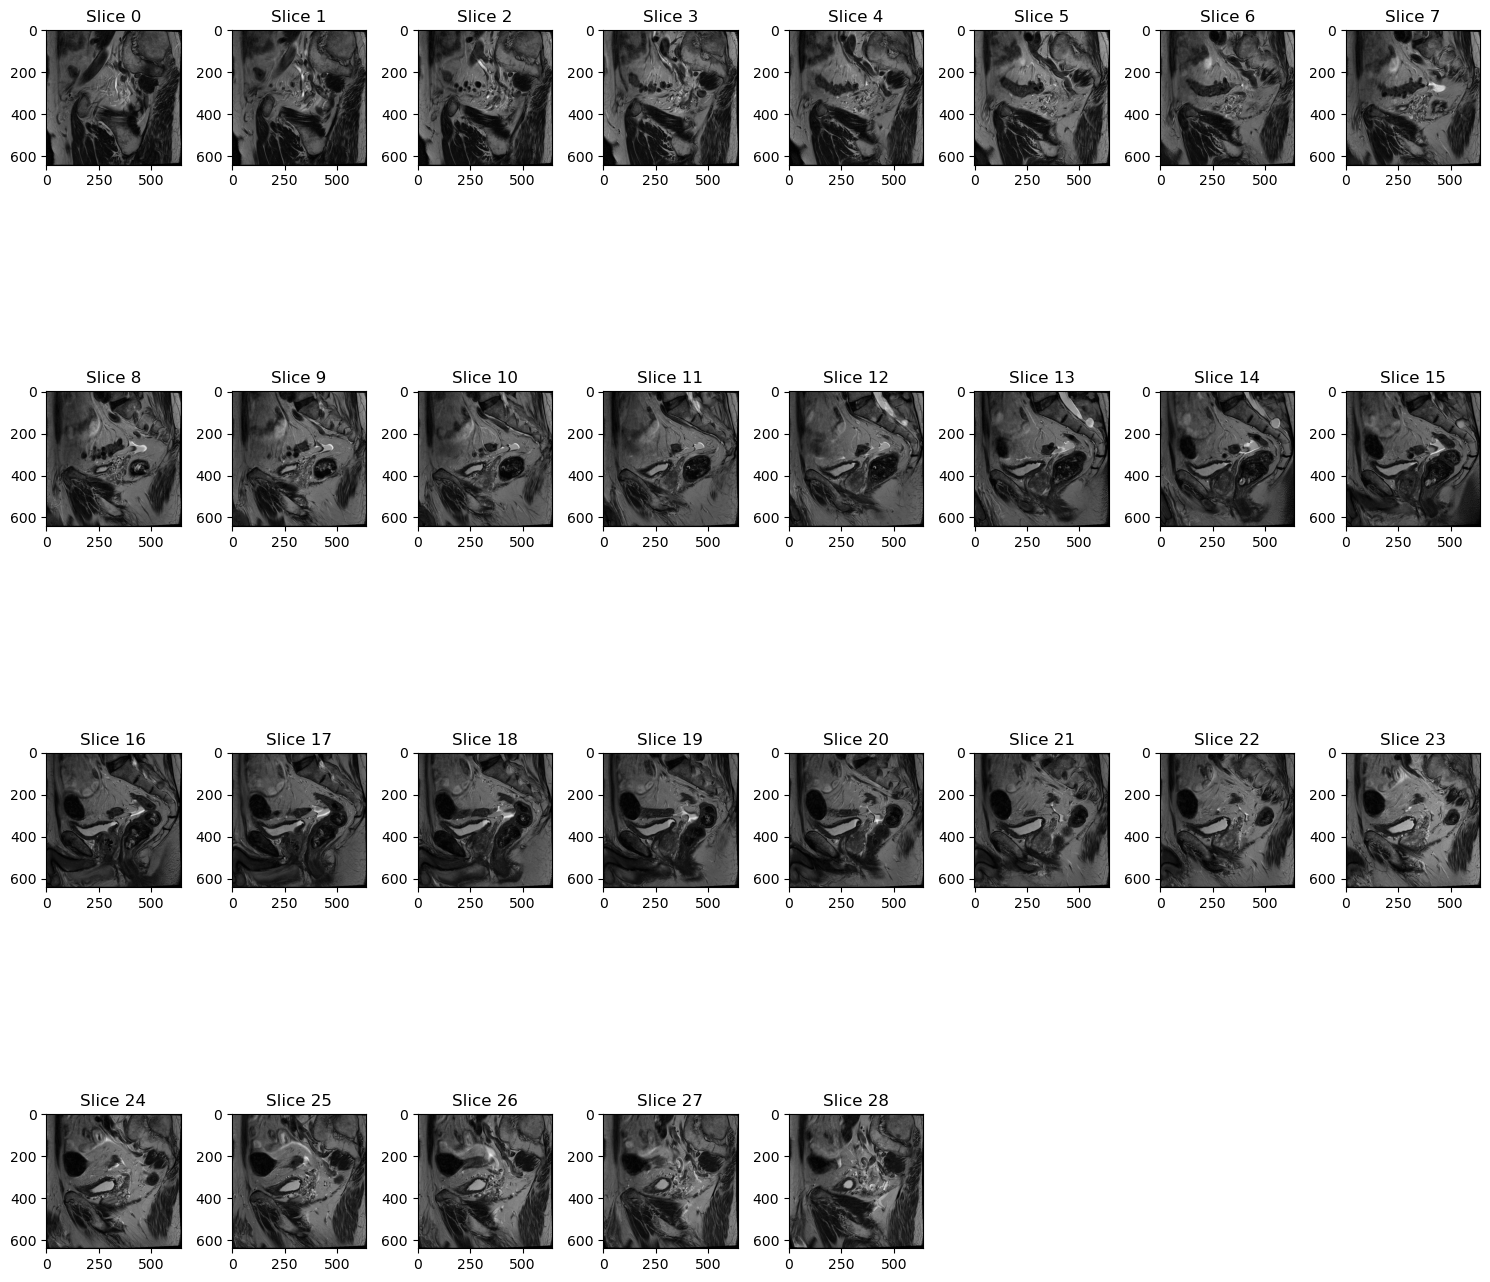

In [27]:
show_image(grouped_files['sag'][0])

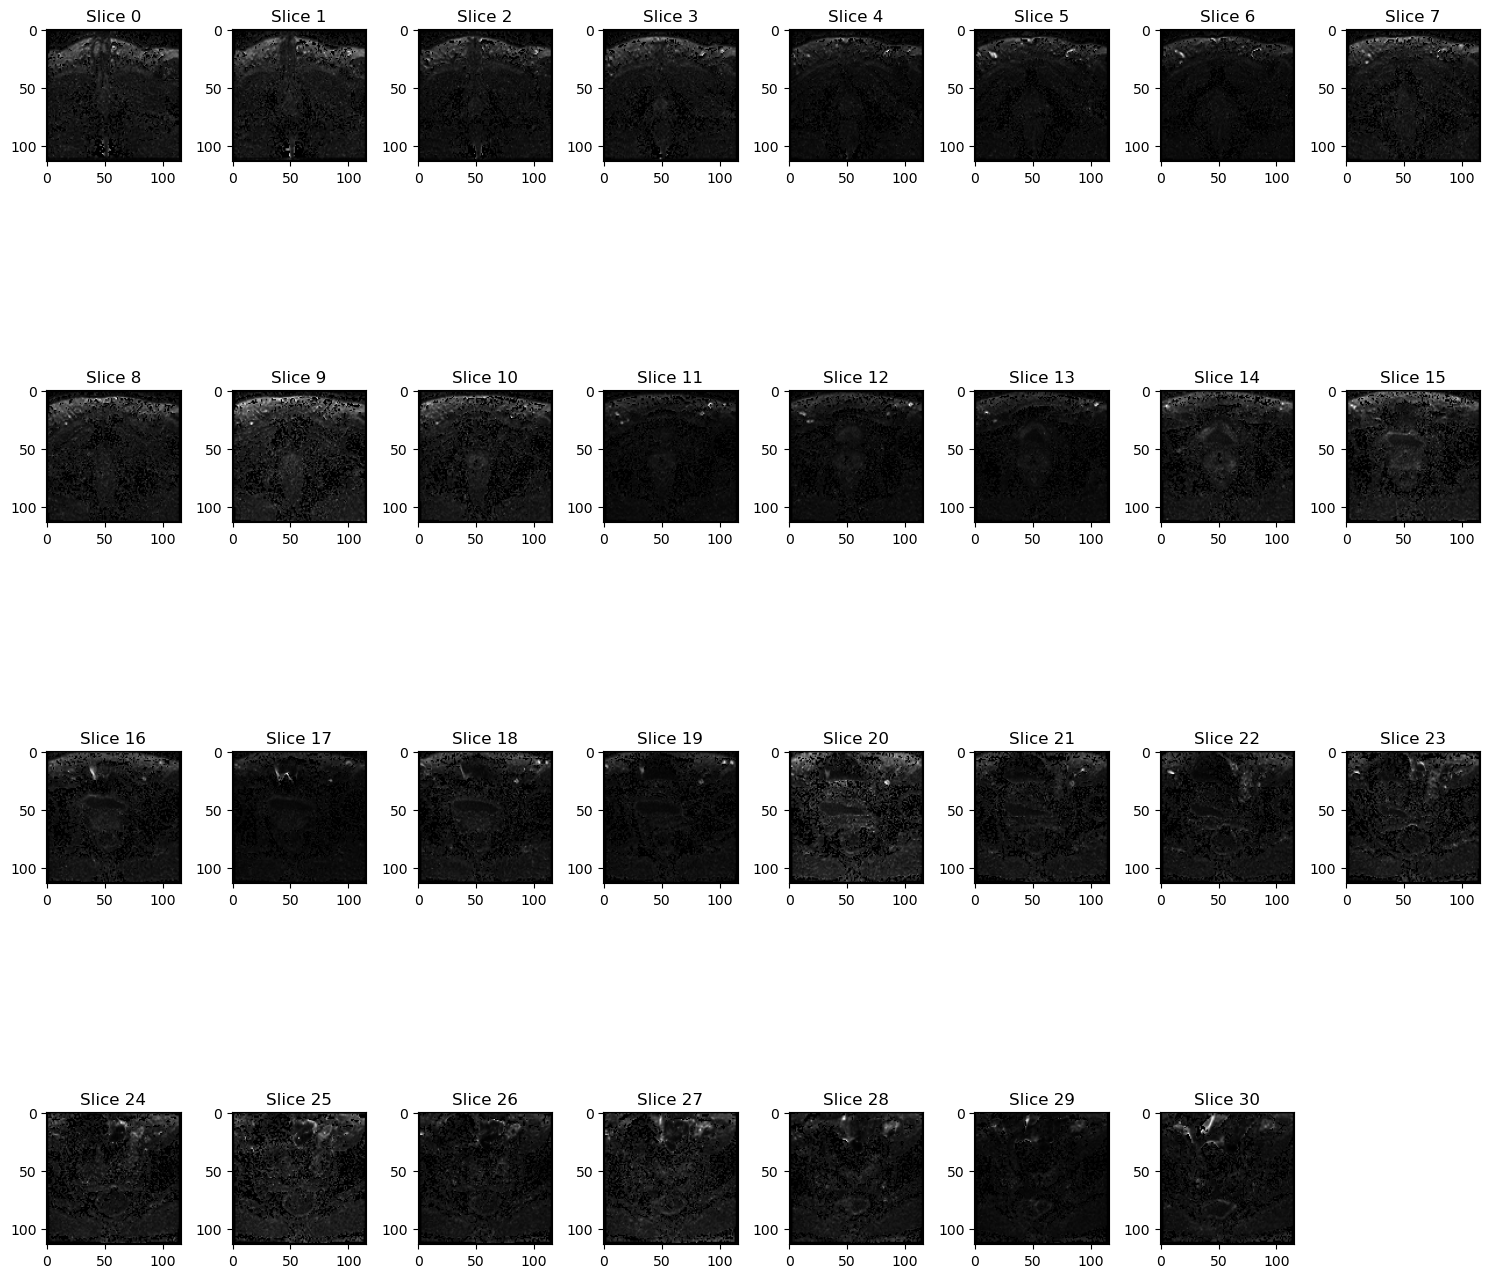

In [28]:
show_image(grouped_files['hbv'][0])

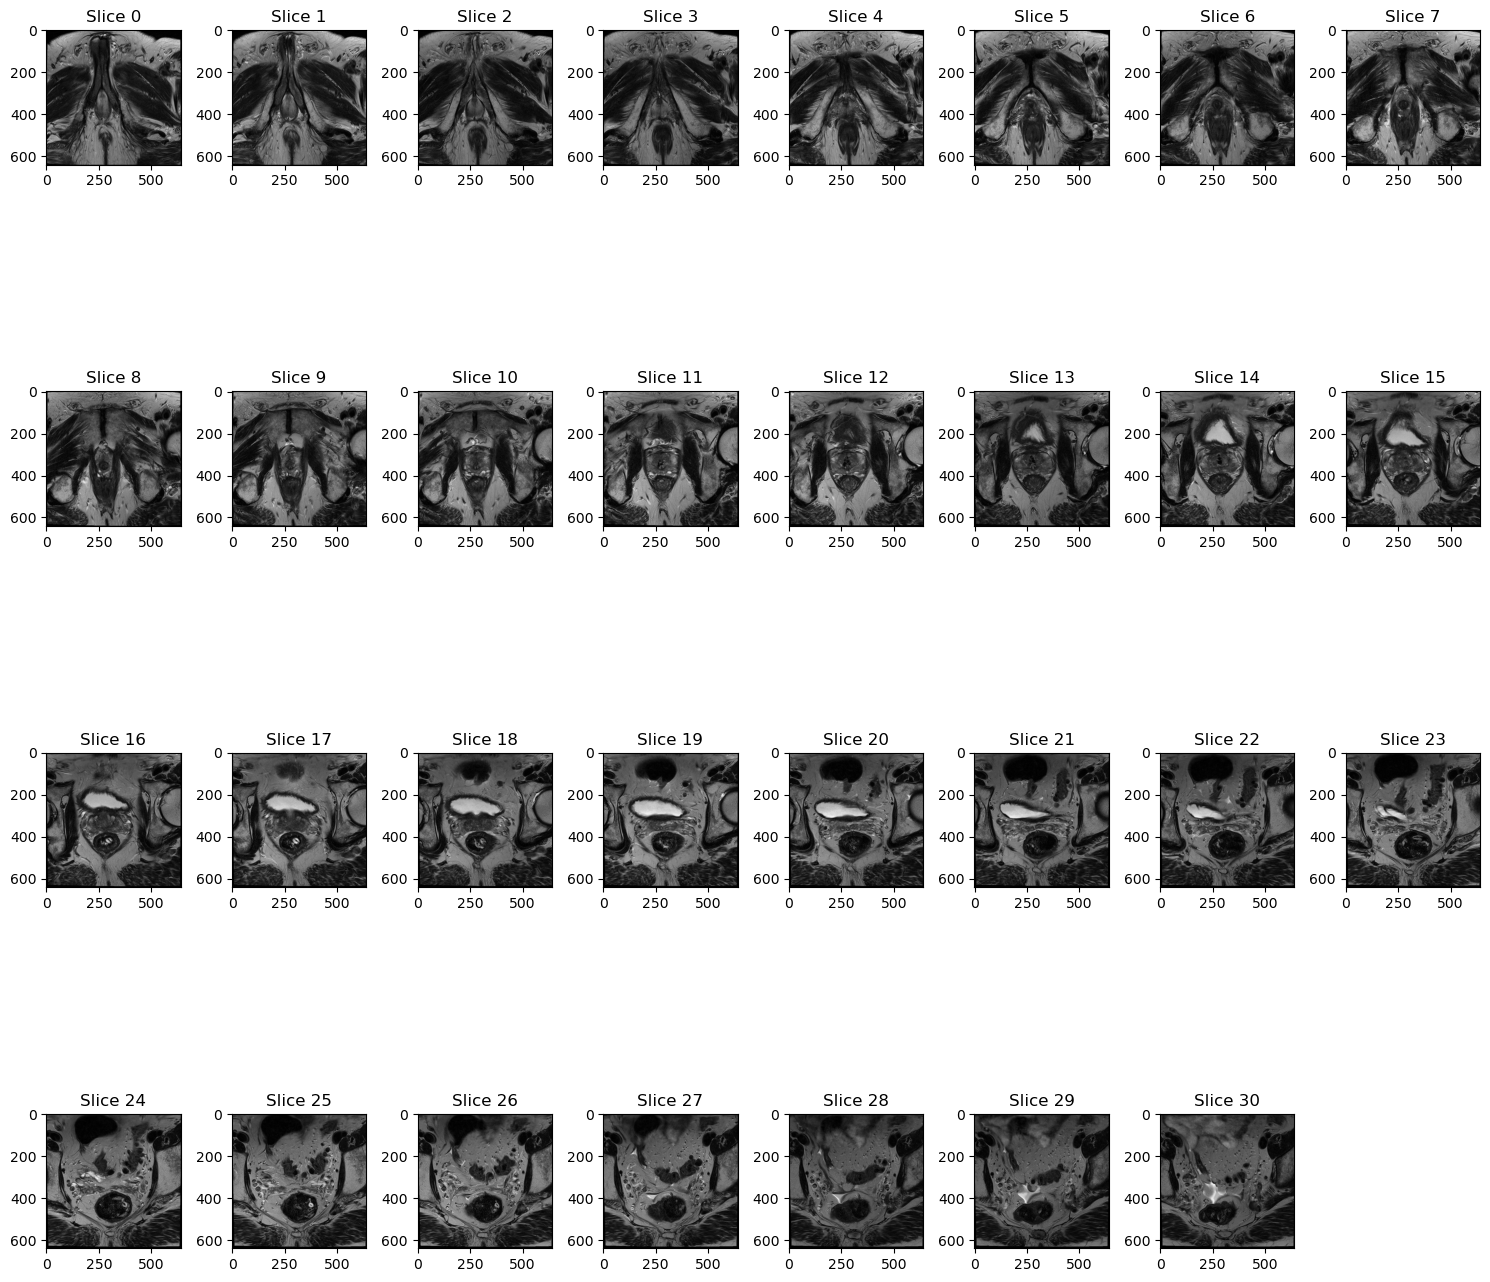

In [29]:
show_image(grouped_files['t2w'][0])

## Data Cleaning (MetaData & Pictures)

In [30]:
df_adc = df_adc.drop(['ITK_InputFilterName', 'ITK_original_direction', 'ITK_original_spacing', 'Modality (Repeated)',
              'ANONYMISATION_SCRIPT', 'Patient Identity Removed', 'Patient\'s Sex',
              'Patient ID', 'Modality', 'Study Date'], axis = 1)

df_cor = df_cor.drop(['ITK_InputFilterName', 'ITK_original_direction', 'ITK_original_spacing', 'Modality (Repeated)',
              'ANONYMISATION_SCRIPT', 'Patient Identity Removed', 'Patient\'s Sex',
              'Patient ID', 'Modality', 'Study Date'], axis = 1)

df_sag = df_sag.drop(['ITK_InputFilterName', 'ITK_original_direction', 'ITK_original_spacing', 'Modality (Repeated)',
              'ANONYMISATION_SCRIPT', 'Patient Identity Removed', 'Patient\'s Sex',
              'Patient ID', 'Modality', 'Study Date'], axis = 1)

df_t2w = df_t2w.drop(['ITK_InputFilterName', 'ITK_original_direction', 'ITK_original_spacing', 'Modality (Repeated)',
              'ANONYMISATION_SCRIPT', 'Patient Identity Removed', 'Patient\'s Sex',
              'Patient ID', 'Modality', 'Study Date'], axis = 1)

df_hbv = df_hbv.drop(['ITK_InputFilterName', 'ITK_original_direction', 'ITK_original_spacing', 'Modality_(Repeated)',
              'ANONYMISATION_SCRIPT', 'Patient_Identity_Removed', 'Patient\'s_Sex',
              'Patient_ID', 'Modality', 'Study_Date'], axis = 1)

In [31]:
df_adc.set_index('Study Instance UID', inplace=True)
df_cor.set_index('Study Instance UID', inplace=True)
df_sag.set_index('Study Instance UID', inplace=True)
df_t2w.set_index('Study Instance UID', inplace=True)
df_hbv.set_index('Study Instance_UID', inplace=True)

In [32]:
df_hbv['path'].duplicated().any()

False

In [33]:
df_hbv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 1000000 to 1001498
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Manufacturer                           300 non-null    object 
 1   Manufacturer's_Model_Name              300 non-null    object 
 2   Patient's_Age                          300 non-null    int64  
 3   Diffusion_sensitization_factor sec/mm  300 non-null    float64
 4   PROSTATE_VOLUME_REPORT                 296 non-null    float64
 5   PSAD_REPORT                            207 non-null    float64
 6   PSA_REPORT                             293 non-null    float64
 7   path                                   300 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 21.1+ KB


In [34]:
df_hbv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 1000000 to 1001498
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Manufacturer                           300 non-null    object 
 1   Manufacturer's_Model_Name              300 non-null    object 
 2   Patient's_Age                          300 non-null    int64  
 3   Diffusion_sensitization_factor sec/mm  300 non-null    float64
 4   PROSTATE_VOLUME_REPORT                 296 non-null    float64
 5   PSAD_REPORT                            207 non-null    float64
 6   PSA_REPORT                             293 non-null    float64
 7   path                                   300 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 21.1+ KB


In [35]:
df_adc.isnull().sum()

Manufacturer                  0
Manufacturer's Model Name     0
Patient's Age                 0
PROSTATE_VOLUME_REPORT       61
PSAD_REPORT                  36
PSA_REPORT                   64
path                          0
dtype: int64

In [36]:
df_hbv.isna().sum()

Manufacturer                              0
Manufacturer's_Model_Name                 0
Patient's_Age                             0
Diffusion_sensitization_factor sec/mm     0
PROSTATE_VOLUME_REPORT                    4
PSAD_REPORT                              93
PSA_REPORT                                7
path                                      0
dtype: int64

In [37]:
df_hbv = df_hbv.dropna(axis=0)
df_sag = df_sag.dropna(axis=0)
df_adc = df_adc.dropna(axis=0)
df_cor = df_cor.dropna(axis=0)
df_t2w = df_t2w.dropna(axis=0)

In [38]:
print(df_hbv.shape)
print(df_sag.shape)
print(df_adc.shape)
print(df_cor.shape)
print(df_t2w.shape)

(205, 8)
(205, 7)
(205, 7)
(205, 7)
(205, 7)


In [39]:
print(df_adc.isnull().sum())
print("-"*70)
print(df_hbv.isnull().sum())
print("-"*70)
print(df_sag.isnull().sum())
print("-"*70)
print(df_cor.isnull().sum())
print("-"*70)
print(df_t2w.isnull().sum())
print("-"*70)

Manufacturer                 0
Manufacturer's Model Name    0
Patient's Age                0
PROSTATE_VOLUME_REPORT       0
PSAD_REPORT                  0
PSA_REPORT                   0
path                         0
dtype: int64
----------------------------------------------------------------------
Manufacturer                             0
Manufacturer's_Model_Name                0
Patient's_Age                            0
Diffusion_sensitization_factor sec/mm    0
PROSTATE_VOLUME_REPORT                   0
PSAD_REPORT                              0
PSA_REPORT                               0
path                                     0
dtype: int64
----------------------------------------------------------------------
Manufacturer                 0
Manufacturer's Model Name    0
Patient's Age                0
PROSTATE_VOLUME_REPORT       0
PSAD_REPORT                  0
PSA_REPORT                   0
path                         0
dtype: int64
-----------------------------------------

In [40]:
df_adc.compare(df_cor)

path  \
                                                                 self   
Study Instance UID                                                      
1000001             picai_public_images_fold0/10001/10001_1000001_...   
1000006             picai_public_images_fold0/10006/10006_1000006_...   
1000020             picai_public_images_fold0/10020/10020_1000020_...   
1000023             picai_public_images_fold0/10023/10023_1000023_...   
1000029             picai_public_images_fold0/10029/10029_1000029_...   
...                                                               ...   
1001475             picai_public_images_fold0/11451/11451_1001475_...   
1001491             picai_public_images_fold0/11467/11467_1001491_...   
1001493             picai_public_images_fold0/11469/11469_1001493_...   
1001495             picai_public_images_fold0/11471/11471_1001495_...   
1001497             picai_public_images_fold0/11473/11473_1001497_...   

                                                                       
                                                                other  
Study Instance UID                                                     
1000001             picai_public_images_fold0/10001/10001_1000001_...  
1000006             picai_public_images_fold0/10006/10006_1000006_...  
1000020             picai_public_images_fold0/10020/10020_1000020_...  
1000023             picai_public_images_fold0/10023/10023_1000023_...  
1000029             picai_public_images_fold0/10029/10029_1000029_...  
...                                                               ...  
1001475             picai_public_images_fold0/11451/11451_1001475_...  
1001491             picai_public_images_fold0/11467/11467_1001491_...  
1001493             picai_public_images_fold0/11469/11469_1001493_...  
1001495             picai_public_images_fold0/11471/11471_1001495_...  
1001497             picai_public_images_fold0/11473/11473_1001497_...  

[205 rows x 2 columns]

In [41]:
print(df_hbv.index.equals(df_adc.index))
print(df_adc.index.equals(df_t2w.index))
print(df_t2w.index.equals(df_cor.index))
print(df_cor.index.equals(df_sag.index))
print(df_sag.index.equals(df_hbv.index))

True
True
True
True
True


In [ ]:
paths = list(df_hbv['path']) + list(df_adc['path']) + list(df_cor['path']) + list(df_sag['path']) + list(df_t2w['path'])

destination = 'Dataset_v1'
os.makedirs(destination, exist_ok=True)

for path in paths:
    shutil.copy(path, destination)

files_v1 = os.listdir(path='Dataset_v1/')
name_list = []
for i in sorted(os.listdir(path='Dataset_v1/')):
    name_list.append(f'Dataset_v1/{i}')

grouped_files = {"adc": [], "cor": [], "hbv": [], "sag": [], "t2w": []}

for path in name_list:
    suffix = path.split('_')[-1].split('.')[0]
    grouped_files[suffix].append(path)

grouped_files = dict(grouped_files)

{'adc': ['Dataset_v1/10001_1000001_adc.mha',
  'Dataset_v1/10006_1000006_adc.mha',
  'Dataset_v1/10020_1000020_adc.mha',
  'Dataset_v1/10023_1000023_adc.mha',
  'Dataset_v1/10029_1000029_adc.mha',
  'Dataset_v1/10032_1000032_adc.mha',
  'Dataset_v1/10033_1000033_adc.mha',
  'Dataset_v1/10038_1000038_adc.mha',
  'Dataset_v1/10040_1000040_adc.mha',
  'Dataset_v1/10059_1000059_adc.mha',
  'Dataset_v1/10062_1000062_adc.mha',
  'Dataset_v1/10071_1000071_adc.mha',
  'Dataset_v1/10073_1000073_adc.mha',
  'Dataset_v1/10078_1000078_adc.mha',
  'Dataset_v1/10092_1000092_adc.mha',
  'Dataset_v1/10129_1000129_adc.mha',
  'Dataset_v1/10136_1000138_adc.mha',
  'Dataset_v1/10146_1000148_adc.mha',
  'Dataset_v1/10156_1000159_adc.mha',
  'Dataset_v1/10158_1000161_adc.mha',
  'Dataset_v1/10165_1000168_adc.mha',
  'Dataset_v1/10167_1000170_adc.mha',
  'Dataset_v1/10177_1000180_adc.mha',
  'Dataset_v1/10189_1000192_adc.mha',
  'Dataset_v1/10193_1000196_adc.mha',
  'Dataset_v1/10195_1000199_adc.mha',
  'Da

In [45]:
df_adc['path'] = grouped_files['adc']
df_cor['path'] = grouped_files['cor']
df_hbv['path'] = grouped_files['hbv']
df_sag['path'] = grouped_files['sag']
df_t2w['path'] = grouped_files['t2w']

## Making_Dataset

In [46]:
df_adc.to_csv('df_adc.csv')
df_cor.to_csv('df_cor.csv')
df_sag.to_csv('df_sag.csv')
df_t2w.to_csv('df_t2w.csv')
df_hbv.to_csv('df_hbv.csv')